# Chapter 29 — NumPy Arrays

Earlier chapters represented vectors, matrices, and tensors with Python lists so every operation stayed visible.

Real numerical code usually delegates those loops to an array library.

NumPy gives us regular numerical arrays and efficient operations without changing the underlying mathematics.

## Learning goals

By the end of this chapter, you should be able to:

1. Explain what a NumPy array is.
2. Convert Python lists into arrays and inspect shape, rank, and data type.
3. Redo vector addition, scalar multiplication, and dot products in NumPy.
4. Redo matrix-vector and matrix-matrix multiplication in NumPy.
5. Distinguish elementwise `*` from matrix multiplication `@`.
6. Compare pure-Python and NumPy results with assertions.
7. Interpret a simple timing comparison carefully.
8. Explain NumPy's trailing-axis broadcasting rule.
9. Use broadcasting intentionally to add bias vectors.
10. Detect an accidental broadcasting bug with shape checks.

## NumPy changes the implementation, not the math

Vector addition is still coordinate-by-coordinate addition.

A dot product still multiplies corresponding coordinates and sums them.

Matrix multiplication still creates row-column dot products.

NumPy replaces many explicit Python loops with concise operations implemented by optimized numerical code.

## Terms used in this chapter

A **NumPy array** is a regular numerical container with a shape, rank, and data type.

An **elementwise operation** applies an operation to corresponding entries.

**Matrix multiplication** uses linear-algebra shape rules and row-column dot products.

**Broadcasting** compares shapes from their trailing axes and virtually extends size-1 or missing axes when compatible.

An **accidental broadcasting bug** occurs when a legal broadcast has the wrong meaning for the program.

## Convert lists into NumPy arrays

Import NumPy in the first cell that creates an array.

In [1]:
import numpy as np

print("NumPy version:", np.__version__)

pure_python_vector = [2.0, -1.0, 3.5]
numpy_vector = np.array(pure_python_vector)

print("Python value:", pure_python_vector)
print("Python type:", type(pure_python_vector))
print("NumPy value:", numpy_vector)
print("NumPy type:", type(numpy_vector))

NumPy version: 2.4.3
Python value: [2.0, -1.0, 3.5]
Python type: <class 'list'>
NumPy value: [ 2.  -1.   3.5]
NumPy type: <class 'numpy.ndarray'>


The list and array hold the same three coordinate values, but the NumPy object supplies numerical-array operations and metadata.

In [2]:
pure_python_matrix = [
    [1.0, 2.0, 3.0],
    [4.0, 5.0, 6.0],
]
numpy_matrix = np.array(pure_python_matrix)

print("Vector shape:", numpy_vector.shape)
print("Vector rank:", numpy_vector.ndim)
print("Vector dtype:", numpy_vector.dtype)
print()
print("Matrix:")
print(numpy_matrix)
print("Matrix shape:", numpy_matrix.shape)
print("Matrix rank:", numpy_matrix.ndim)
print("Matrix dtype:", numpy_matrix.dtype)

Vector shape: (3,)
Vector rank: 1
Vector dtype: float64

Matrix:
[[1. 2. 3.]
 [4. 5. 6.]]
Matrix shape: (2, 3)
Matrix rank: 2
Matrix dtype: float64


The vector shape `(3,)` has one axis of size 3.

The matrix shape `(2, 3)` has two rows and three columns.

The `dtype` records the kind of value stored in every array entry.

## Pure-Python reference operations

We will keep small manual implementations as references, then verify that NumPy produces the same results.

In [3]:
from collections.abc import Sequence


def assert_vector_of_numbers(vector: Sequence[object]) -> None:
    if len(vector) == 0:
        raise ValueError("A vector must contain at least one number.")

    for position, coordinate in enumerate(vector):
        is_number = isinstance(coordinate, (int, float))

        if not is_number or isinstance(coordinate, bool):
            raise TypeError(
                f"Coordinate at position {position} must be an int or float."
            )


def assert_same_vector_dimension(
    first_vector: list[float],
    second_vector: list[float],
) -> None:
    assert_vector_of_numbers(first_vector)
    assert_vector_of_numbers(second_vector)

    if len(first_vector) != len(second_vector):
        raise ValueError("Vectors must have the same dimension.")


def add_vectors(
    first_vector: list[float],
    second_vector: list[float],
) -> list[float]:
    assert_same_vector_dimension(first_vector, second_vector)

    return [
        first_vector[position] + second_vector[position]
        for position in range(len(first_vector))
    ]


def multiply_vector_by_scalar(
    scalar: float,
    vector: list[float],
) -> list[float]:
    assert_vector_of_numbers(vector)

    return [scalar * coordinate for coordinate in vector]


def dot_product(
    first_vector: list[float],
    second_vector: list[float],
) -> float:
    assert_same_vector_dimension(first_vector, second_vector)

    total = 0.0

    for position in range(len(first_vector)):
        total = total + first_vector[position] * second_vector[position]

    return total

## Vector operations in NumPy

The operators `+` and `*` act elementwise on same-shaped vectors, while `@` computes their dot product.

In [4]:
first_vector = [2.0, -1.0, 3.5]
second_vector = [0.5, 4.0, -2.0]
scalar = 3.0

first_array = np.array(first_vector)
second_array = np.array(second_vector)

numpy_vector_sum = first_array + second_array
numpy_scaled_vector = scalar * first_array
numpy_elementwise_product = first_array * second_array
numpy_dot_product = first_array @ second_array

print("Vector sum:", numpy_vector_sum)
print("Scaled vector:", numpy_scaled_vector)
print("Elementwise product:", numpy_elementwise_product)
print("Dot product:", numpy_dot_product)

Vector sum: [2.5 3.  1.5]
Scaled vector: [ 6.  -3.  10.5]
Elementwise product: [ 1. -4. -7.]
Dot product: -10.0


The elementwise product has shape `(3,)`, while the dot product is a scalar with shape `()`.

In [5]:
print("Elementwise product shape:", numpy_elementwise_product.shape)
print("Dot-product shape:", numpy_dot_product.shape)

assert np.allclose(add_vectors(first_vector, second_vector), numpy_vector_sum)
assert np.allclose(
    multiply_vector_by_scalar(scalar, first_vector),
    numpy_scaled_vector,
)
assert np.isclose(dot_product(first_vector, second_vector), numpy_dot_product)

print("All pure-Python and NumPy vector results match.")

Elementwise product shape: (3,)
Dot-product shape: ()
All pure-Python and NumPy vector results match.


`np.allclose` compares arrays while allowing tiny floating-point differences.

`np.isclose` is the corresponding scalar comparison.

## Pure-Python matrix references

The matrix helpers validate rectangular shapes and implement multiplication with the dot product.

In [6]:
def get_matrix_shape(matrix: list[list[float]]) -> tuple[int, int]:
    if len(matrix) == 0 or len(matrix[0]) == 0:
        raise ValueError("A matrix must contain rows and columns.")

    number_of_columns = len(matrix[0])

    for row in matrix:
        if len(row) != number_of_columns:
            raise ValueError("Every matrix row must have the same length.")

    return len(matrix), number_of_columns


def get_matrix_column(
    matrix: list[list[float]],
    column_index: int,
) -> list[float]:
    _, number_of_columns = get_matrix_shape(matrix)

    if column_index < 0 or column_index >= number_of_columns:
        raise ValueError("column_index is outside the matrix.")

    return [row[column_index] for row in matrix]


def multiply_matrix_by_vector(
    matrix: list[list[float]],
    vector: list[float],
) -> list[float]:
    _, number_of_columns = get_matrix_shape(matrix)

    if len(vector) != number_of_columns:
        raise ValueError("Matrix columns must equal vector length.")

    return [dot_product(row, vector) for row in matrix]


def multiply_matrices(
    first_matrix: list[list[float]],
    second_matrix: list[list[float]],
) -> list[list[float]]:
    first_rows, first_columns = get_matrix_shape(first_matrix)
    second_rows, second_columns = get_matrix_shape(second_matrix)

    if first_columns != second_rows:
        raise ValueError("Matrix inner dimensions must match.")

    result = []

    for row_index in range(first_rows):
        result_row = []

        for column_index in range(second_columns):
            column = get_matrix_column(second_matrix, column_index)
            result_row.append(dot_product(first_matrix[row_index], column))

        result.append(result_row)

    return result

## Matrix-vector multiplication

A `(2, 3)` matrix can multiply a length-3 vector and produce a length-2 vector.

In [7]:
matrix = [
    [1.0, 2.0, 3.0],
    [4.0, 5.0, 6.0],
]
vector = [10.0, 20.0, 30.0]

python_matrix_vector_result = multiply_matrix_by_vector(matrix, vector)
numpy_matrix_vector_result = np.array(matrix) @ np.array(vector)

print("Matrix shape:", np.array(matrix).shape)
print("Vector shape:", np.array(vector).shape)
print("Result shape:", numpy_matrix_vector_result.shape)
print("Pure Python result:", python_matrix_vector_result)
print("NumPy result:", numpy_matrix_vector_result)

assert np.allclose(python_matrix_vector_result, numpy_matrix_vector_result)

Matrix shape: (2, 3)
Vector shape: (3,)
Result shape: (2,)
Pure Python result: [140.0, 320.0]
NumPy result: [140. 320.]


NumPy's `@` performs the same two row-vector dot products as the manual function.

## Matrix multiplication

The product `(2 × 3) @ (3 × 4)` has shape `(2, 4)` because the inner dimensions match.

In [8]:
first_matrix = [
    [1.0, 2.0, 3.0],
    [4.0, 5.0, 6.0],
]
second_matrix = [
    [10.0, 20.0, 30.0, 40.0],
    [50.0, 60.0, 70.0, 80.0],
    [90.0, 100.0, 110.0, 120.0],
]

first_matrix_array = np.array(first_matrix)
second_matrix_array = np.array(second_matrix)

python_matrix_result = multiply_matrices(first_matrix, second_matrix)
numpy_matrix_result = first_matrix_array @ second_matrix_array

print("First shape:", first_matrix_array.shape)
print("Second shape:", second_matrix_array.shape)
print("Result shape:", numpy_matrix_result.shape)
print("NumPy result:")
print(numpy_matrix_result)

assert np.allclose(python_matrix_result, numpy_matrix_result)

First shape: (2, 3)
Second shape: (3, 4)
Result shape: (2, 4)
NumPy result:
[[ 380.  440.  500.  560.]
 [ 830.  980. 1130. 1280.]]


`*` would attempt an elementwise operation, while `@` performs matrix multiplication.

The two input matrices have different shapes, so their elementwise multiplication is not defined.

In [9]:
try:
    first_matrix_array * second_matrix_array
except ValueError as error:
    print("Caught expected elementwise shape error:")
    print(error)

try:
    first_matrix_array @ np.array([[1.0, 2.0], [3.0, 4.0]])
except ValueError as error:
    print()
    print("Caught expected matrix-multiplication shape error:")
    print(error)

Caught expected elementwise shape error:
operands could not be broadcast together with shapes (2,3) (3,4) 

Caught expected matrix-multiplication shape error:
matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 2 is different from 3)


The errors come from different rules, so choosing the intended operator matters.

## Higher-rank language-model arrays

NumPy arrays also represent the batch shapes introduced in Chapter 28.

In [10]:
input_token_ids = np.array(
    [
        [0, 1, 2, 3],
        [0, 2, 3, 4],
    ]
)
target_token_ids = np.array(
    [
        [1, 2, 3, 4],
        [2, 3, 4, 1],
    ]
)
embeddings = np.array(
    [
        [
            [0.10, 0.20, 0.30],
            [0.40, 0.50, 0.60],
            [0.70, 0.80, 0.90],
            [1.00, 1.10, 1.20],
        ],
        [
            [1.30, 1.40, 1.50],
            [1.60, 1.70, 1.80],
            [1.90, 2.00, 2.10],
            [2.20, 2.30, 2.40],
        ],
    ]
)
logits = np.array(
    [
        [
            [2.0, 0.1, -1.0, 0.5, 1.2],
            [0.3, 1.7, -0.4, 0.2, 0.0],
            [-0.5, 0.6, 2.1, 0.3, -0.2],
            [1.0, -0.1, 0.4, 1.8, 0.2],
        ],
        [
            [1.5, 0.2, -0.7, 0.4, 1.0],
            [0.1, 1.4, -0.3, 0.8, 0.2],
            [-0.4, 0.9, 1.9, 0.1, -0.5],
            [0.7, 0.0, 0.5, 1.6, 0.3],
        ],
    ]
)

print("input token IDs:", input_token_ids.shape, input_token_ids.dtype)
print("target token IDs:", target_token_ids.shape, target_token_ids.dtype)
print("embeddings:", embeddings.shape, embeddings.dtype)
print("logits:", logits.shape, logits.dtype)

input token IDs: (2, 4) int64
target token IDs: (2, 4) int64
embeddings: (2, 4, 3) float64
logits: (2, 4, 5) float64


Token IDs use integer entries, while embeddings and logits use floating-point entries.

Their shapes retain the axis meanings established in the previous chapter.

## Index and slice arrays

Comma-separated NumPy indexes follow the same axis order as nested-list indexes.

A colon keeps every entry along an axis.

In [11]:
selected_token_id = input_token_ids[1, 2]
selected_embedding = embeddings[0, 2, :]
selected_example_embeddings = embeddings[0, :, :]

print("Selected token ID:", selected_token_id)
print("Selected embedding:", selected_embedding)
print("Selected embedding shape:", selected_embedding.shape)
print("One example's embedding shape:", selected_example_embeddings.shape)

Selected token ID: 3
Selected embedding: [0.7 0.8 0.9]
Selected embedding shape: (3,)
One example's embedding shape: (4, 3)


Integer indexing removes an axis, while `:` preserves the selected axis.

## A small batch transformation

A batch matrix shaped `examples × input coordinates` can multiply a parameter matrix shaped `input coordinates × output coordinates`.

In [12]:
batch_matrix = np.array(
    [
        [1.0, 0.0, 2.0],
        [0.5, -1.0, 1.5],
    ]
)
parameter_matrix = np.array(
    [
        [0.2, 0.5, -0.1, 1.0],
        [1.5, -0.3, 0.8, 0.0],
        [-0.7, 0.4, 0.6, -0.2],
    ]
)

numpy_batch_output = batch_matrix @ parameter_matrix
python_batch_output = multiply_matrices(
    batch_matrix.tolist(),
    parameter_matrix.tolist(),
)

print("Batch shape:", batch_matrix.shape)
print("Parameter shape:", parameter_matrix.shape)
print("Output shape:", numpy_batch_output.shape)
print("Output:")
print(numpy_batch_output)

assert np.allclose(python_batch_output, numpy_batch_output)

Batch shape: (2, 3)
Parameter shape: (3, 4)
Output shape: (2, 4)
Output:
[[-1.2   1.3   1.1   0.6 ]
 [-2.45  1.15  0.05  0.2 ]]


The shape rule `(2 × 3) @ (3 × 4) = (2 × 4)` transforms both examples at once.

A complete linear layer will later add a bias vector to this output.

## An illustrative timing comparison

Wall-clock timing depends on the machine, numerical libraries, thread settings, and current system load.

The exact stored values are therefore illustrative rather than a portable benchmark.

We use fixed input values, warm up both implementations, time several runs, and compare median time per multiplication.

In [13]:
import statistics
import time
from collections.abc import Callable


def median_operation_seconds(
    operation: Callable[[], object],
    number_of_runs: int,
) -> float:
    if number_of_runs < 1:
        raise ValueError("number_of_runs must be at least 1.")

    durations = []

    for _ in range(number_of_runs):
        start_time = time.perf_counter()
        operation()
        durations.append(time.perf_counter() - start_time)

    return statistics.median(durations)


random_generator = np.random.default_rng(29)
first_timing_array = random_generator.normal(size=(80, 100))
second_timing_array = random_generator.normal(size=(100, 60))
first_timing_matrix = first_timing_array.tolist()
second_timing_matrix = second_timing_array.tolist()

# Warm-up avoids including one-time setup in the measured calls.
multiply_matrices(first_timing_matrix, second_timing_matrix)
first_timing_array @ second_timing_array

python_seconds = median_operation_seconds(
    lambda: multiply_matrices(first_timing_matrix, second_timing_matrix),
    number_of_runs=3,
)
numpy_seconds = median_operation_seconds(
    lambda: first_timing_array @ second_timing_array,
    number_of_runs=30,
)

python_timing_result = multiply_matrices(
    first_timing_matrix,
    second_timing_matrix,
)
numpy_timing_result = first_timing_array @ second_timing_array

assert np.allclose(python_timing_result, numpy_timing_result)

print("Input shapes:", first_timing_array.shape, second_timing_array.shape)
print(f"Pure Python median: {python_seconds * 1000:.3f} ms")
print(f"NumPy median:       {numpy_seconds * 1000:.3f} ms")
print("Numerical results match.")

Input shapes: (80, 100) (100, 60)
Pure Python median: 169.146 ms
NumPy median:       0.025 ms
Numerical results match.


The numerical assertion is the important correctness check.

The timing values demonstrate this particular run and should not be treated as universal performance guarantees.

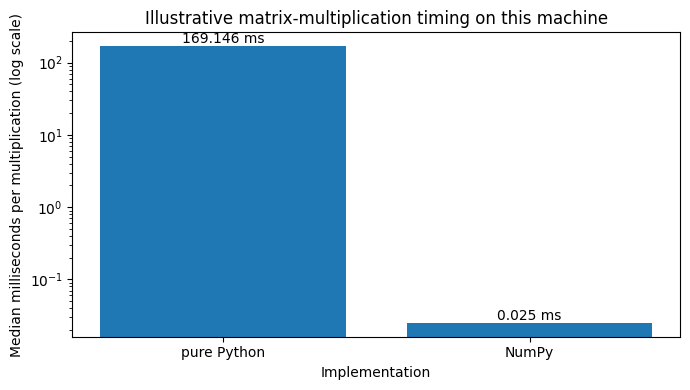

In [14]:
import matplotlib.pyplot as plt

method_names = ["pure Python", "NumPy"]
milliseconds = [python_seconds * 1000, numpy_seconds * 1000]

figure, axes = plt.subplots(figsize=(7, 4))
bars = axes.bar(method_names, milliseconds)
axes.set_yscale("log")
axes.set_xlabel("Implementation")
axes.set_ylabel("Median milliseconds per multiplication (log scale)")
axes.set_title("Illustrative matrix-multiplication timing on this machine")

for bar, value in zip(bars, milliseconds, strict=True):
    axes.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.3f} ms",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

The logarithmic scale keeps both bars visible even when their runtimes differ substantially.

NumPy gains speed from optimized compiled numerical routines, not from changing the operation.

## Broadcasting compares trailing axes

NumPy compares shapes from right to left.

Two axis sizes are compatible when they are equal or one of them is 1.

If one shape has fewer leading axes, NumPy treats the missing leading sizes as 1.

Broadcasting behaves like extending values across compatible axes without requiring us to manually copy them first.

### Broadcast a row vector across matrix rows

Shapes `(2, 3)` and `(3,)` align on their trailing size 3, so the vector is applied to both rows.

In [15]:
broadcast_matrix = np.array(
    [
        [1.0, 2.0, 3.0],
        [4.0, 5.0, 6.0],
    ]
)
row_vector = np.array([10.0, 20.0, 30.0])
row_broadcast_result = broadcast_matrix + row_vector

print("Matrix shape:", broadcast_matrix.shape)
print("Row-vector shape:", row_vector.shape)
print("Result shape:", row_broadcast_result.shape)
print(row_broadcast_result)

Matrix shape: (2, 3)
Row-vector shape: (3,)
Result shape: (2, 3)
[[11. 22. 33.]
 [14. 25. 36.]]


### Broadcast a column-shaped array across columns

Shapes `(2, 3)` and `(2, 1)` align because the trailing sizes 3 and 1 are compatible.

In [16]:
column_vector = np.array(
    [
        [100.0],
        [200.0],
    ]
)
column_broadcast_result = broadcast_matrix + column_vector

print("Matrix shape:", broadcast_matrix.shape)
print("Column-array shape:", column_vector.shape)
print("Result shape:", column_broadcast_result.shape)
print(column_broadcast_result)

Matrix shape: (2, 3)
Column-array shape: (2, 1)
Result shape: (2, 3)
[[101. 102. 103.]
 [204. 205. 206.]]


The shape `(2, 1)` means one value per row, so each value extends across that row's three columns.

## Useful broadcasting: add one bias per output coordinate

A bias shaped `(4,)` can be added to a batch output shaped `(2, 4)`.

The final axis matches, so the same four-coordinate bias is applied to every example row.

In [17]:
bias = np.array([0.1, 0.2, 0.3, 0.4])
biased_batch_output = numpy_batch_output + bias

print("Batch output shape:", numpy_batch_output.shape)
print("Bias shape:", bias.shape)
print("Biased output shape:", biased_batch_output.shape)
print("Biased output:")
print(biased_batch_output)

assert biased_batch_output.shape == numpy_batch_output.shape

Batch output shape: (2, 4)
Bias shape: (4,)
Biased output shape: (2, 4)
Biased output:
[[-1.1   1.5   1.4   1.  ]
 [-2.35  1.35  0.35  0.6 ]]


This is intentional broadcasting and previews the bias addition in a linear layer.

## Accidental broadcasting can silently change shape

Suppose predictions and targets should each be one value per example with shape `(3,)`.

If targets accidentally have shape `(3, 1)`, subtraction is still legal but produces every pairwise difference in a `(3, 3)` matrix.

In [18]:
predictions = np.array([10.0, 20.0, 30.0])
correct_targets = np.array([12.0, 18.0, 33.0])
accidental_targets = np.array(
    [
        [12.0],
        [18.0],
        [33.0],
    ]
)

correct_errors = predictions - correct_targets
accidental_errors = predictions - accidental_targets

print("Predictions shape:", predictions.shape)
print("Correct targets shape:", correct_targets.shape)
print("Correct errors shape:", correct_errors.shape)
print("Accidental targets shape:", accidental_targets.shape)
print("Accidental errors shape:", accidental_errors.shape)
print("Accidental pairwise differences:")
print(accidental_errors)

Predictions shape: (3,)
Correct targets shape: (3,)
Correct errors shape: (3,)
Accidental targets shape: (3, 1)
Accidental errors shape: (3, 3)
Accidental pairwise differences:
[[ -2.   8.  18.]
 [ -8.   2.  12.]
 [-23. -13.  -3.]]


NumPy correctly followed its broadcasting rules, but those rules did not know the program intended one error per example.

Legal shapes are not automatically semantically correct shapes.

## Guard important boundaries with shape checks

An explicit shape assertion turns the accidental broadcast into a readable error before subtraction.

In [19]:
import numpy.typing as npt


def assert_shape(
    array: npt.NDArray[np.generic],
    expected_shape: tuple[int, ...],
    name: str,
) -> None:
    if array.shape != expected_shape:
        raise ValueError(
            f"{name} has shape {array.shape}, but expected {expected_shape}."
        )


assert_shape(predictions, (3,), "predictions")
assert_shape(correct_targets, (3,), "correct_targets")
assert_shape(correct_errors, (3,), "correct_errors")

try:
    assert_shape(accidental_targets, (3,), "accidental_targets")
except ValueError as error:
    print("Caught expected shape error:")
    print(error)

Caught expected shape error:
accidental_targets has shape (3, 1), but expected (3,).


Broadcasting remains useful, but exact checks protect places where the program requires one specific shape.

## Broadcasting meaning in language-model arrays

Logits shaped `batch × context × vocabulary` can accept a vocabulary bias shaped `(vocabulary,)`.

The same bias is applied at every batch example and token position.

In [20]:
vocabulary_bias = np.array([0.01, 0.02, 0.03, 0.04, 0.05])
biased_logits = logits + vocabulary_bias

print("Logits shape:", logits.shape)
print("Vocabulary-bias shape:", vocabulary_bias.shape)
print("Biased-logits shape:", biased_logits.shape)

assert vocabulary_bias.shape == (logits.shape[-1],)
assert biased_logits.shape == logits.shape

Logits shape: (2, 4, 5)
Vocabulary-bias shape: (5,)
Biased-logits shape: (2, 4, 5)


By contrast, an array shaped `(batch, 1, 1)` would mean one added scalar per batch example.

Both broadcasts are legal, but their axis meanings differ.

In [21]:
per_example_offset = np.array(
    [
        [[10.0]],
        [[20.0]],
    ]
)
offset_logits = logits + per_example_offset

print("Logits shape:", logits.shape)
print("Per-example offset shape:", per_example_offset.shape)
print("Result shape:", offset_logits.shape)
print("Batch 0 first logit before and after:", logits[0, 0, 0], offset_logits[0, 0, 0])
print("Batch 1 first logit before and after:", logits[1, 0, 0], offset_logits[1, 0, 0])

Logits shape: (2, 4, 5)
Per-example offset shape: (2, 1, 1)
Result shape: (2, 4, 5)
Batch 0 first logit before and after: 2.0 12.0
Batch 1 first logit before and after: 1.5 21.5


The operation is not inherently wrong, but it would be a bug if the intended parameter were one bias per vocabulary token.

Names and shape checks connect legal array mechanics to intended model meaning.

## A clean NumPy pipeline

The final cell verifies vector operations, matrix multiplication, intended bias broadcasting, and rejection of an accidental target shape.

In [22]:
pipeline_first_vector = [2.0, -1.0, 3.5]
pipeline_second_vector = [0.5, 4.0, -2.0]

pipeline_first_array = np.array(pipeline_first_vector)
pipeline_second_array = np.array(pipeline_second_vector)

assert np.allclose(
    add_vectors(pipeline_first_vector, pipeline_second_vector),
    pipeline_first_array + pipeline_second_array,
)
assert np.isclose(
    dot_product(pipeline_first_vector, pipeline_second_vector),
    pipeline_first_array @ pipeline_second_array,
)
assert np.allclose(
    multiply_matrices(first_matrix, second_matrix),
    first_matrix_array @ second_matrix_array,
)

pipeline_biased_output = numpy_batch_output + bias
assert pipeline_biased_output.shape == numpy_batch_output.shape

try:
    assert_shape(accidental_targets, predictions.shape, "accidental_targets")
except ValueError as error:
    print("Caught expected broadcasting guard:")
    print(error)

print()
print("NumPy pipeline summary")
print("-" * 48)
print("Vector sum:", pipeline_first_array + pipeline_second_array)
print("Dot product:", pipeline_first_array @ pipeline_second_array)
print("Matrix product shape:", numpy_matrix_result.shape)
print("Biased batch shape:", pipeline_biased_output.shape)
print("All numerical comparisons passed.")

Caught expected broadcasting guard:
accidental_targets has shape (3, 1), but expected (3,).

NumPy pipeline summary
------------------------------------------------
Vector sum: [2.5 3.  1.5]
Dot product: -10.0
Matrix product shape: (2, 4)
Biased batch shape: (2, 4)
All numerical comparisons passed.


## What not to do

- Do not assume NumPy changes the mathematics established in earlier chapters.
- Do not confuse elementwise `*` with linear-algebra `@`.
- Do not stop naming and checking axes because array syntax is shorter.
- Do not require exact floating-point equality when `np.allclose` or `np.isclose` is appropriate.
- Do not treat every legal broadcast as a semantically correct operation.
- Do not present one machine's timing as a universal benchmark.

## Gotchas

An array's `.shape`, `.ndim`, and `.dtype` describe different properties.

`*` performs elementwise multiplication, while `@` performs dot products or matrix multiplication according to rank.

Broadcasting compares trailing axes, and axis sizes are compatible when equal or when one size is 1.

A shape `(3, 1)` can broadcast with `(3,)` into `(3, 3)`, even when one-to-one subtraction was intended.

Wall-clock timings vary, while numerical equivalence can be checked reliably.

## Takeaways

NumPy arrays provide concise, efficient implementations of the vector, matrix, and tensor operations developed with Python lists.

Shape awareness remains essential because shorter syntax does not remove compatibility rules or axis meanings.

Use `np.allclose` and `np.isclose` to verify floating-point results, `@` for linear-algebra multiplication, and explicit checks at important shape boundaries.

Broadcasting is powerful when its expanded axes match the intended meaning and dangerous when a legal expansion hides a shape mistake.

## What comes next

The next chapter uses NumPy arrays for token IDs and embedding tables.

Indexing an embedding table with token IDs will produce the first concrete embedding lookup, a central language-model operation.